<a href="https://colab.research.google.com/github/Helomaylima/cn2026/blob/main/Atividade0209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática II - Estabilidade e Overflow


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


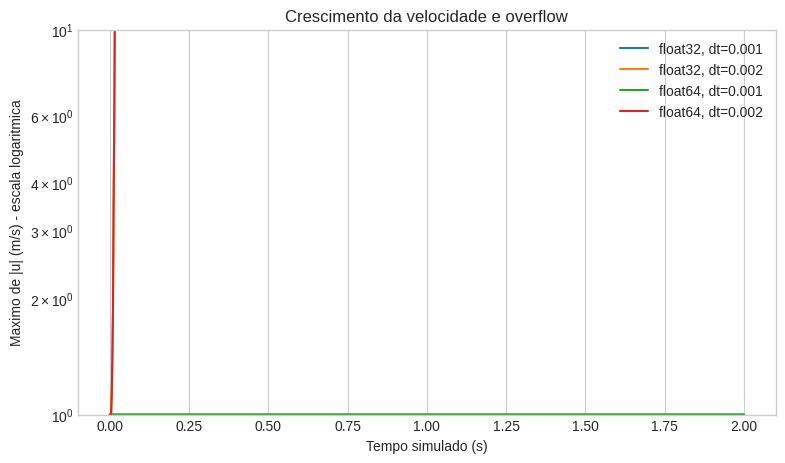

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## Respostas das Atividades Propostas

### 1. Verificação da estabilidade
Com base nos dados da simulação ($H=0,01$ m e $\nu=10^{-4}$ m²/s):
* **Espaçamento ($\Delta y$):** $\Delta y = 0,01 / (21 - 1) = 0,0005$ m.
* **Limite de tempo ($\Delta t_{max}$):** $\Delta t_{max} = (0,0005)^2 / (2 \times 10^{-4}) = 0,00125$ s.

Análise antes da execução:
* **Caso A ($\Delta t = 0,001$ s):** $r = 0,4$. Como $r \le 0,5$, classificamos como **ESTÁVEL**.
* **Caso B ($\Delta t = 0,002$ s):** $r = 0,8$[cite: 1]. Como $r > 0,5$, classificamos como **INSTÁVEL**.

### 2. Detecção de overflow (Tabela)
Abaixo, geramos a tabela com os resultados capturados pela simulação executada na célula anterior:

In [11]:
import pandas as pd

dados_tabela = []
for nome, res in resultados.items():
    tipo_num, dt_str = nome.split(', dt=')
    dados_tabela.append({
        "Tipo Numérico": tipo_num,
        "Passo de Tempo (dt)": dt_str,
        "Valor de r": round(res["r"], 1),
        "Ocorrência de Overflow?": "Sim" if res["falha"] is not None else "Não",
        "Iteração da Falha": res["falha"] if res["falha"] is not None else "Nenhuma falha"
    })

df = pd.DataFrame(dados_tabela)
display(df)

,Tipo Numérico,Passo de Tempo (dt),Valor de r,Ocorrência de Overflow?,Iteração da Falha
0,float32,0.001,0.4,Não,Nenhuma falha
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,Nenhuma falha
3,float64,0.002,0.8,Sim,917


### 3. Interpretação física
No gráfico gerado, a velocidade cresce descontroladamente nos casos instáveis. Isso **não representa o comportamento físico esperado**, pois a placa superior é fixa (0 m/s) e a inferior se move a 1 m/s[cite: 1]. O fluido entre elas não pode ultrapassar a velocidade de 1 m/s, pois não há geração de energia, apenas transferência por viscosidade.

### 4. Capacidade de representação
A mudança de `float32` para `float64` **não elimina a instabilidade**[cite: 1]. A instabilidade ocorre por uma falha matemática do método quando $r > 0,5$[cite: 1].
A diferença no número de passos até a falha acontece porque o `float64` tem muito mais memória e suporta números até cerca de $1,8 \times 10^{308}$, enquanto o maior valor finito aproximado do `float32` é de $3,4 \times 10^{38}$[cite: 1]. O `float64` apenas "aguenta o erro" por mais iterações antes de dar overflow, mas a simulação já estava incorreta muito antes.

Novo espaçamento (dy): 0.00025 m
Novo limite de estabilidade (dt_max): 0.0003125 s

dt=0.0002, float64: 5000 passos sem overflow.
Diferença máxima (E_inf) em relação ao perfil estacionário: 0.000033 m/s


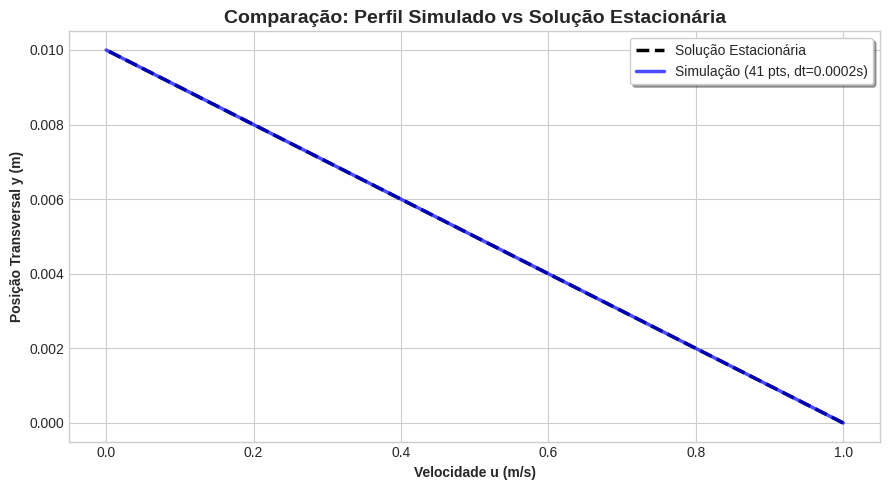

In [12]:
H = 0.01
nu = 1e-4
novos_pontos = 41

novo_dy = H / (novos_pontos - 1)
novo_dt_max = (novo_dy**2) / (2 * nu)

print(f"Novo espaçamento (dy): {novo_dy:.5f} m")
print(f"Novo limite de estabilidade (dt_max): {novo_dt_max:.7f} s\n")

dt_escolhido = 0.0002
res_refinado = simular(dt=dt_escolhido, tipo=np.float64, passos=5000, pontos=novos_pontos)

U = 1.0
y_malha = res_refinado["y"]
u_simulacao = res_refinado["u"]
u_estacionaria = U * (1 - y_malha / H)

e_inf = np.max(np.abs(u_simulacao - u_estacionaria))
print(f"Diferença máxima (E_inf) em relação ao perfil estacionário: {e_inf:.6f} m/s")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(9, 5))
plt.plot(u_estacionaria, y_malha, 'k--', label='Solução Estacionária', linewidth=2.5)
plt.plot(u_simulacao, y_malha, 'b-', label='Simulação (41 pts, dt=0.0002s)', linewidth=2.5, alpha=0.7)
plt.ylabel("Posição Transversal y (m)", fontweight='bold')
plt.xlabel("Velocidade u (m/s)", fontweight='bold')
plt.title("Comparação: Perfil Simulado vs Solução Estacionária", fontsize=14, fontweight='bold')
plt.legend(frameon=True, shadow=True, facecolor='white')
plt.tight_layout()
plt.show()

### 5. Discussão sobre o Refinamento (Continuação)
Ao passarmos para 41 pontos, o espaçamento caiu pela metade. Isso fez o limite de estabilidade cair 4 vezes ($\Delta t_{max} = 0,0003125$ s). Se mantivéssemos o $\Delta t = 0,001$ s, a simulação falharia rapidamente. Por isso, utilizamos $\Delta t = 0,0002$ s, mantendo o método estável.

### 6. Verificação do Perfil de velocidade
Como observado no valor de $E_{\infty}$ (muito próximo de zero), a diferença entre a simulação e a reta teórica foi mínima. Isso significa que o tempo simulado **foi suficiente** para o fluido sair do regime transiente e atingir o regime estacionário pleno.

### 7. Conclusão
* **Refinar a malha** (aumentar pontos) exige passos no tempo ($\Delta t$) muito menores, pois a estabilidade depende do quadrado do espaçamento ($\Delta y^2$).
* A **instabilidade numérica** ocorre quando o passo de tempo ultrapassa o limite da física do problema. O erro cresce até causar o **overflow**(quando falta memória no tipo numérico para guardar um valor tão grande).
* A alteração que corrigiu a falha foi **reduzir o passo de tempo ($\Delta t$)**, respeitando a condição de estabilidade para esse esquema de difusão ($r \le 0,5$).